In [101]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import GridSearchCV


In [14]:
heart_data=pd.read_csv("157 - heart-disease.csv")


In [15]:
heart_data.target.value_counts()

target
1    165
0    138
Name: count, dtype: int64

<Axes: xlabel='target'>

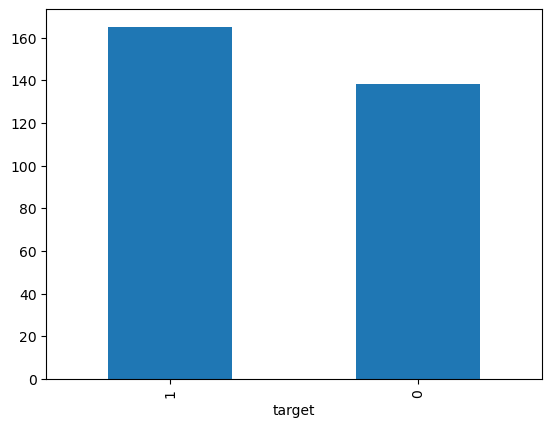

In [16]:
heart_data.target.value_counts().plot(kind='bar')

In [17]:
heart_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [18]:
heart_data[heart_data['target'] == 1]['age'].value_counts()

age
54    10
41     9
52     9
51     9
44     8
57     7
58     7
42     7
64     6
53     6
45     6
56     5
43     5
59     5
48     4
50     4
66     4
65     4
46     4
62     4
63     3
49     3
71     3
39     3
47     3
55     3
60     3
67     3
37     2
69     2
34     2
35     2
68     2
38     2
61     1
40     1
29     1
74     1
76     1
70     1
Name: count, dtype: int64

In [19]:
pd.crosstab(heart_data.target,heart_data.sex)

sex,0,1
target,,
0,24,114
1,72,93


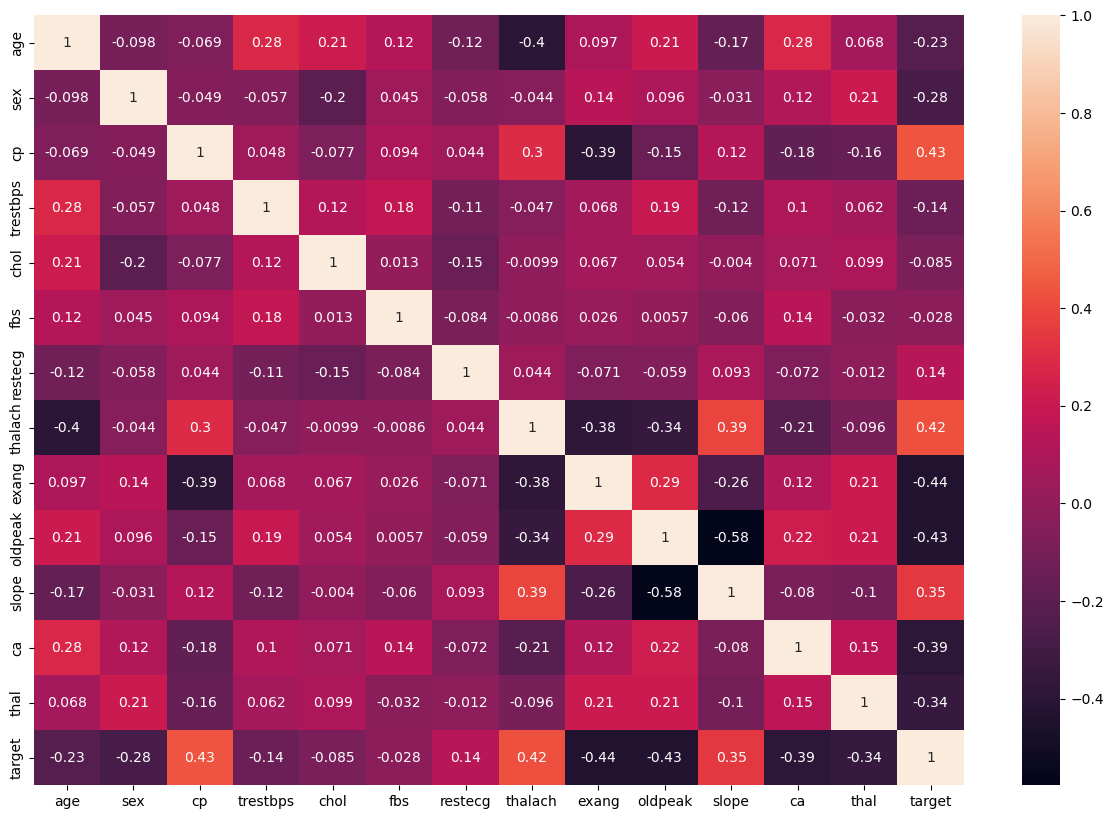

In [20]:
#make a correlation matrix
corr_matrix=heart_data.corr()
fig,ax=plt.subplots(figsize=(15,10)
                    )
ax=sns.heatmap(corr_matrix,annot=True)

In [21]:
x=heart_data.drop('target',axis=1)

y=heart_data['target']



In [22]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2)


In [23]:
models={"Logistic Regression":LogisticRegression(),
        "KNN":KNeighborsClassifier(),
        "Random Forest":RandomForestClassifier()}

def fit_and_score(models,x_train,x_test,y_train,y_test):
    np.random.seed(42)
    model_score={}
    for name,model in models.items():
        model.fit(x_train,y_train)
        model_score[name]=model.score(x_test,y_test)
    return model_score
    

In [ ]:
model_scores=fit_and_score(models=models,x_train=x_train,x_test=x_test,y_train=y_train,y_test=y_test)


d:\CourseWork\PythonCourse\sample_project\env\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [33]:
print(model_scores)


{'Logistic Regression': 0.7704918032786885, 'KNN': 0.6721311475409836, 'Random Forest': 0.7868852459016393}


In [36]:
model_comapre=pd.DataFrame(model_scores,index=["accuracy"])
model_comapre

,Logistic Regression,KNN,Random Forest
accuracy,0.770492,0.672131,0.786885


,accuracy
Logistic Regression,0.770492
KNN,0.672131
Random Forest,0.786885


<Axes: >

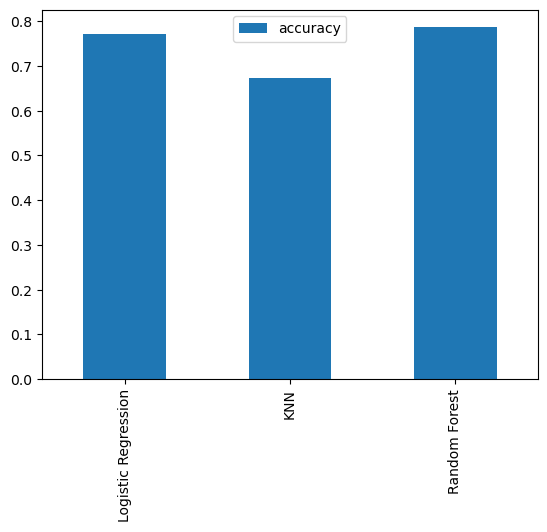

In [40]:
model_comapre.transpose().plot(kind="bar")

In [61]:
train_scores=[]
test_scores=[]

neighbors=range(1,21)
knn=KNeighborsClassifier()
for i in neighbors:
    knn.set_params(n_neighbors=i)
    knn.fit(x_train,y_train)
    train_scores.append(knn.score(x_train,y_train))
    test_scores.append(knn.score(x_test,y_test))
    

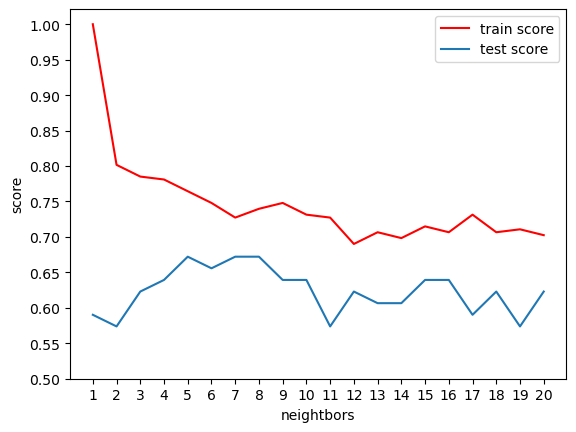

In [62]:
plt.plot(neighbors,train_scores,label="train score",color='red')
plt.plot(neighbors,test_scores,label="test score")
plt.xticks(np.arange(1,21,1))

plt.yticks(np.arange(0.5, 1.05, 0.05))       # more y values

plt.xlabel("neightbors")
plt.ylabel("score")
plt.legend()



In [66]:

index=np.where(test_scores==np.max(test_scores))
print(index[0][0])

4


In [79]:
log_reg_grid={"C":np.logspace(-4,4,20),
              "solver":["liblinear"]
              }
rd_grid={"n_estimators":np.arange(10,1000,50),
         "max_depth":[None,3,5,10],
         "min_samples_split":np.arange(2,20,2),
         "min_samples_leaf":np.arange(1,20,2)}

In [72]:
np.random.seed(42)
rs_log_reg=RandomizedSearchCV(LogisticRegression(),param_distributions=log_reg_grid
                              ,cv=5,
                              n_iter=20,verbose=True)

rs_log_reg.fit(x_train,y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegression()
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'C': array([1.0000...00000000e+04]), 'solver': ['liblinear']}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fol

In [76]:
rs_log_reg.best_params_

{'solver': 'liblinear', 'C': np.float64(0.23357214690901212)}

In [74]:
rs_log_reg.score(x_test,y_test)

0.7540983606557377

In [80]:
np.random.seed(42)
rd_rf=RandomizedSearchCV(RandomForestClassifier(),param_distributions=rd_grid
                         ,cv=5,n_iter=25,
                         verbose=True)

rd_rf.fit(x_train,y_train)
rd_rf.score(x_test,y_test)

Fitting 5 folds for each of 25 candidates, totalling 125 fits


0.7868852459016393

In [81]:
model_scores

{'Logistic Regression': 0.7704918032786885,
 'KNN': 0.6721311475409836,
 'Random Forest': 0.7868852459016393}

In [83]:
log_reg_grid={"C":np.logspace(-4,4,30),
              "solver":["liblinear"]
              }
gs_log_reg=GridSearchCV(LogisticRegression(),
                        param_grid=log_reg_grid,
                        cv=5,
                        verbose=True)
gs_log_reg.fit(x_test,y_test)
gs_log_reg.score(x_test,y_test)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


0.819672131147541

In [89]:
y_pred=gs_log_reg.predict(x_test)
y_pred

array([0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1,
       0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0,
       1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1])

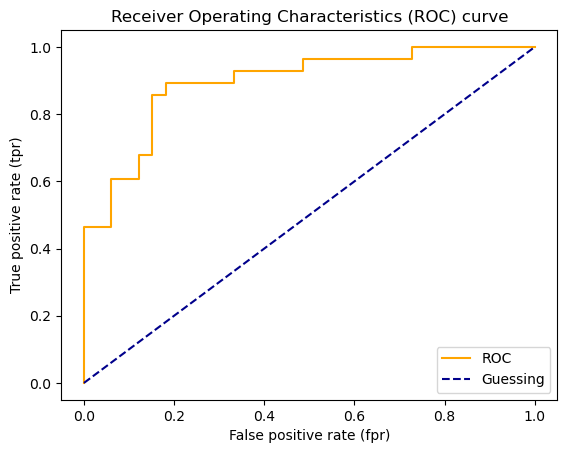

0.893939393939394

In [97]:
from sklearn.metrics import roc_auc_score,roc_curve

y_probs=gs_log_reg.predict_proba(x_test)
y_probs_positive=y_probs[:,1]
y_probs_positive

fpr,tpr,thresholds=roc_curve(y_test,y_probs_positive)
thresholds
def plot_roc_curve(fpr,tpr):
    
    plt.plot(fpr,tpr,color="orange",label="ROC")
    plt.plot([0,1],[0,1],color="darkblue",linestyle='--',label='Guessing')
    plt.xlabel("False positive rate (fpr)")
    plt.ylabel("True positive rate (tpr)")
    plt.title( "Receiver Operating Characteristics (ROC) curve" )
    plt.legend()
    plt.show()


plot_roc_curve(fpr,tpr)
roc_auc_score(y_test,y_probs_positive)
 


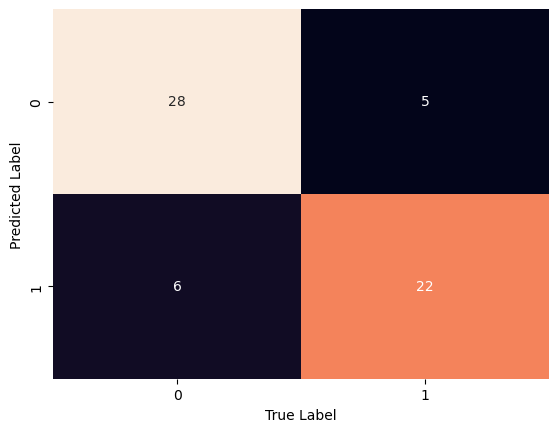

In [98]:
def plot_confusion_matrix(y_test,y_pred):
    fig,ax=plt.subplots()
    ax=sns.heatmap(confusion_matrix(y_test,y_pred),
                   annot=True,
                   cbar=False)
    plt.xlabel("True Label")
    plt.ylabel("Predicted Label")
    
plot_confusion_matrix(y_test=y_test,y_pred=y_pred)

In [99]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.82      0.85      0.84        33
           1       0.81      0.79      0.80        28

    accuracy                           0.82        61
   macro avg       0.82      0.82      0.82        61
weighted avg       0.82      0.82      0.82        61



In [100]:
gs_log_reg.best_params_

{'C': np.float64(0.1082636733874054), 'solver': 'liblinear'}

In [104]:
clf=LogisticRegression(C= 0.10826, solver= 'liblinear')

In [106]:
cv_acc=cross_val_score(clf,x,y,cv=5,scoring="accuracy")
cv_acc=np.mean(cv_acc)
cv_acc

np.float64(0.834808743169399)

In [115]:
cv_precsion=cross_val_score(clf,x,y,cv=5,scoring="precision")
cv_precsion=np.mean(cv_precsion)
cv_precsion

np.float64(0.8182683982683983)

In [116]:
cv_f1=cross_val_score(clf,x,y,cv=5,scoring="f1")
cv_f1=np.mean(cv_f1)
cv_f1

np.float64(0.8572876223964055)

<Axes: >

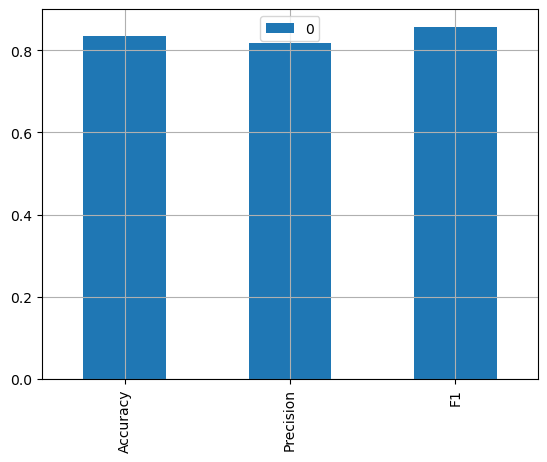

In [ ]:
cv_metrics=pd.DataFrame({"Accuracy":cv_acc,
                         "Precision":cv_precsion,
                         "F1":cv_f1,
                        },index=[0])
cv_metrics.T.plot(kind='bar',grid=True)